# Simulation Analysis

This notebook has been created to help you familiarize yourself with the typical workflow/pipeline and tools we use to decompose and analyze an EMG signal.

The signals we analyze here have been obtained through [*Neuromotion*](), a simulation tool published by professor Farina which has been modified to provide, in addition to the raw signals, also the ground truth of the Motor Units (MUs), as well as the movements performed by the simulated subject.

We will be using the CBSS [*Convolutive Blind Source Separation*]() alghoritm to decompose the signals, but first we must load them.

If you do not have access to the files, you can find them [here](https://drive.google.com/drive/folders/1XAS5F4TdF7ZSzdbt_8j_nHqNKRHmsIb8?usp=sharing), make sure to download them and put them in the data folder of this repo.

## Imports

In [4]:

# Loading/Import related packages
import sys
import os

# Needed to point the importer to the src folder
sys.path.append(os.path.abspath('/Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main'))

#Usual suspects
import pandas as pd
import numpy as np
import json
import pickle as pkl
import matplotlib.pyplot as plt


#Extras for plotting
from matplotlib.patches import Patch

#Extra for typing
from collections import defaultdict

#Decomposition/Processing Imports
from src.muniverse.algorithms.cbss import CBSS


## Loading the signals


Over the course of the thesis, you will find around three thousand different file formats you will have to load and use. Good luck

The three main ones are:

1. Neuromotion Files (which we will be using here): Pickle files containing simulated data produced through the Neuromotion framework. You will be able to find the relevant data structures in the [*gian-Neuromotion*]() repo, present on the GitHub of the Lab.

2. Pipeline Files: Pickle files written by our very own [*recording pipeline*](), whose working we go a bit more in detail in the next Notebook.
   
3. OTBIO+ Files: Not of interest for now (and i hope it stays that way for a while). You can find loading scripts in [otbio_io.py](../src/muniverse/utils/otb_io.py)

In [5]:
#Get the root repository directory (or more correctly the parent directory of the notebooks folder)
# NOTE: __file__ does not exist inside a notebook, so we start from the working directory instead
REPO_DIR  = os.path.abspath(os.path.join(os.getcwd(), '/Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main'))

# Define the input and output directories for the analysis
# The data cannot be included due to its large size: If the directories do not exist, see above for instructions
INPUT_DIR = os.path.join(REPO_DIR, 'data', 'simulated')
OUTPUT_DIR = os.path.join(REPO_DIR, 'results', 'simulated')

filename = 'simulated_data.pkl'





### Note: 

Most of the functions you see here, such as the loading below, are already present in the repo somewhere else. I am rewriting them in this notebook with additional comments, so you can take a better look at them 

Hopefully, I also remembered to insert their original location somewhere in here for reference






In [6]:
def load_simulation_data(input_dir, filename):

    """
    Load the simulation data from a pickle file.

    Parameters:
    - input_dir: str, the directory where the pickle file is located.
    - filename: str, the name of the pickle file.
    - slice_arr: a

    Returns:
    - emg_array: dict, the loaded simulation EMG data. 
    Normally contains 320 channels, here downsampled to the first 8x8 array to make decomposition faster .
    """
    file_path = os.path.join(input_dir, filename)

    # Check if the file exists before attempting to load it
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist. Please ensure the input directory and filename are correct.")

    result_pandas = pd.read_pickle(file_path)
    print("Loaded data from:", file_path)
    print(result_pandas.keys())
    print(result_pandas['emg'].shape)

    #The array generated by the simulation is a 320 channel array, split between several 8x8 arrays.
    #but for the sake of speed, we will only use the first 8x8 array for decomposition

    #The data is formatted as n_rows x n_cols x n_samples, so we can slice it to get the first 8x8 array

    emg_array = result_pandas['emg'][0:8, 0:8, :]

    #These two arrays contain the intended poses and durations for each pose
    # We will use this information later in the analysis, see below in the Decomposition Section
    poses = result_pandas['metadata']['poses_intended']
    durations = result_pandas['metadata']['durations']


    #NOTE: a tuple, not a set: a set has no order, so the unpacking below would be random
    return emg_array, poses, durations
    

In [7]:
emg_array, poses, durations = load_simulation_data(input_dir=INPUT_DIR, filename=filename)

Loaded data from: /Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main/data/simulated/simulated_data.pkl
dict_keys(['emg', 'muaps', 'spikes', 'ext', 'firing_rates', 'ipis', 'ms_lengths', 'parameter_changes', 'metadata', 'sci_metadata'])
(10, 32, 79968)


### EMG signals in the project:

You might be familiar already with EMG signals, but please read this part.

In most of the work and experiments we will be conducting, the signal we record will be split between periods of movement (also called repetitions) and rest.

Most other papers use long (around 20 seconds), isometric (meaning no actual movement performed) and isotonic (stable force) contractions of around 20 seconds for decomposition.

To accomodate the impairments of the experimental subjects of our experiments, which might not be able to perform the contractions for such a long time, we instead opted to record several, shorter movements of around 5 seconds each. 

We then concatenate their signals together, deleting the periods of rest, and use the 20 seconds of emg signal during movement to perform decomposition

In [9]:
# A basic plotting function to visualize the emg is something like this
# Requires sampling frequency or fs, to map between emg samples and time
# fs is usually 2048 Hz, unless specified 

def plot_emg_with_movement(emg_array, poses, durations, fs, channel=(0, 0), ax=None):

    """
    Plot a single EMG channel, with a coloured patch behind each pose.

    Parameters:
    - emg_array: np.ndarray, either n_rows x n_cols x n_samples (grid) or n_channels x n_samples (flat).
    - poses: sequence of str, the name of the pose performed in each block, in order.
    - durations: sequence of float, the duration in seconds of each pose, same order as poses.
    - fs: float, the sampling frequency of the EMG in Hz.
    - channel: (row, col) for a grid array, or an int for a flat one.
    - ax: optional matplotlib axis, so this can be reused inside bigger figures.

    Returns:
    - ax: the axis the signal was drawn on.
    """

    # We usually show the trace of a single channel for visualization purposes,
    # but we might also use the RMS if the movement is not clearly visible above noise
    emg_array = np.asarray(emg_array)

    if emg_array.ndim == 3:
        row, col = channel
        signal = emg_array[row, col, :]
        ch_label = f"channel ({row}, {col})"
    else:
        ch = channel if isinstance(channel, int) else channel[0]
        signal = emg_array[ch, :]
        ch_label = f"channel {ch}"

    # The signal is stored sample by sample, so we build the time axis ourselves
    t = np.arange(signal.size) / fs

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))

    # One colour per unique pose name: if the same pose is repeated later in the recording,
    # it keeps the same colour (dict.fromkeys preserves the order of first appearance)
    unique_poses = list(dict.fromkeys(poses))
    cmap = plt.get_cmap('tab10' if len(unique_poses) <= 10 else 'tab20') # tab10 lists 10 distinct colors, 20 for tab20
    colors = {pose: cmap(i % cmap.N) for i, pose in enumerate(unique_poses)} # give each pose a color

    # The poses are performed one after the other, so a pose starts where the previous ones ended:
    # the cumulative sum of the durations gives us the boundaries of every block, in seconds
    edges = np.concatenate(([0.0], np.cumsum(durations))) 

    for pose, start, end in zip(poses, edges[:-1], edges[1:]):
        # Clipped to the end of the signal, in case the durations add up to more than what was recorded
        ax.axvspan(min(start, t[-1]), min(end, t[-1]), color=colors[pose], alpha=0.25, lw=0)

    ax.plot(t, signal, color='0.15', lw=0.4)

    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'EMG - {ch_label}')
    ax.set_title('EMG signal with intended poses')

    # A patch legend, one entry per pose, drawn with the same alpha as the patches
    handles = [Patch(facecolor=colors[pose], alpha=0.25, label=pose) for pose in unique_poses]
    ax.legend(handles=handles, fontsize=8, loc='upper right', ncol=min(len(handles), 4))

    return ax



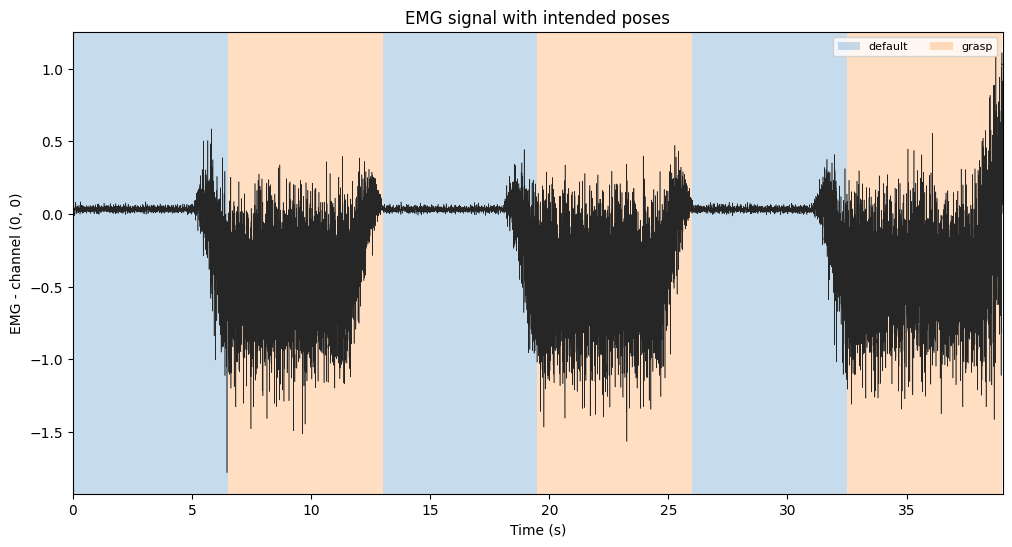

In [10]:
plot_emg_with_movement(emg_array, poses, durations, fs=2048)
plt.show()

In [76]:
print("Poses of the recording: ", poses)

print("Duration of each Transition: ", durations)

print("Read Below if you are curious about how poses and durations work\n")

Poses of the recording:  ['default', 'default', 'grasp', 'grasp', 'default', 'default', 'grasp', 'grasp', 'default', 'default', 'grasp', 'grasp', 'default']
Duration of each Transition:  [5, 1.5, 5, 1.5, 5, 1.5, 5, 1.5, 5, 1.5, 5, 1.5]
Read Below if you are curious about how poses and durations work



### Concatening Movement Data

NOTE: This information is not strictly necessary if you will be doing mostly experimental work, it's mainly for the folks who will be working on alghoritm development and might make extensive use of NeuroMotion.  





----------------------------------------------

Following what we said above, we want to take and decompose the emg signals during movement.

For some reason, Neuromotion sets up movements in what are called "transitions": without going too much into detail, it works as follows

We have two states:

'rest': patient is at rest

'fist': patient is doing a fist

To simulate a subject closing their fist and then opening it again, we have to define the following chain

```python

poses = [rest, fist, fist, rest]

duration = [1.5, 3, 1.5]

```

Meaning that the patient will start at rest, move onto fist in the span of 1.5 seconds, stay in "fist" for 3 seconds and then relax again in 1.5

The function below defines as rest-fist the first 1.5 seconds, rest-holding (fist-holding?) as the three seconds of closed fist and fist-rest the last transition

All the emg signals associated with each of these movements will be assigned a key with the names from the previous paragraph and out into thee dictionary *concatenated_signals*

If I later have need to analyze the signal during the fist to rest transition I will call 

```python
concatenated_signals["fist-rest"]
```
or as in our case we need the signal during the held movement we call 

```python
concatenated_signals["fist-holding"]
```

In [11]:
# A function to take the EMG signal as is and dividing it 
# in different transitions

fs = 2048


def extract_transitions_by_type(emg_signal, durations, poses, fs):
    """
    Extract and concatenate EMG signals by transition type.
    
    Parameters:
    -----------
    emg_signal : np.ndarray
        EMG signal with shape (n_channels, n_samples)
    durations : list
        List of durations in seconds for each pose
    poses : list
        List of pose names (e.g., ['default', 'grasp', ...])
    fs : int
        Sampling frequency in Hz
    
    Returns:
    --------
    dict : Dictionary with transition types as keys and concatenated EMG segments as values
    """
    transition_signals = defaultdict(list)
    
    # Calculate start and end times for each segment
    current_time = 0
    phases = []
    
    for i, (duration, pose) in enumerate(zip(durations, poses)):
        start_time = current_time
        end_time = current_time + duration
        
        # Determine transition type
        if i == len(poses) - 1:
                # Last segment - no next pose
                transition_type = f"{pose}-end"
        else:
            next_pose = poses[i+1]
            if next_pose == pose: ##### When would this occur?? Shouldn't each pose be followed by a different one?? ####
                # And in this case, how would you determine the duration of each pose if it appears to be continuous from the same pose to the next?
                # Same pose as previous = holding
                transition_type = f"{pose}-holding"
            else:
                # Transition from one pose to another
                transition_type = f"{pose}-{next_pose}"
        
        phases.append({
            'start': start_time,
            'end': end_time,
            'duration': duration,
            'pose': pose,
            'type': transition_type,
            'index': i
        })
        
        current_time = end_time
    
    # Extract EMG segments for each phase
    for phase in phases:
        phase_type = phase['type']
        start_idx = int(phase['start'] * fs)
        end_idx = int(phase['end'] * fs)
        
        # Make sure we don't exceed the signal length
        end_idx = min(end_idx, emg_signal.shape[1])
        
        signal_segment = emg_signal[:, start_idx:end_idx]
        transition_signals[phase_type].append(signal_segment)
    
    # Concatenate all segments of the same type
    concatenated_signals = {
        transition_type: np.concatenate(segments, axis=1) 
        for transition_type, segments in transition_signals.items()
    }
    
    return concatenated_signals, phases

In [12]:
# extract_transitions_by_type slices the signal along its second axis, so it expects
# a flat (n_channels x n_samples) array: we flatten the 8x8 grid into 64 channels first.
# The mapping is row-major (each row stored first, then move on to the next), so channel index = row * 8 + col 
emg_flat = emg_array.reshape(-1, emg_array.shape[-1])
##### use reshape(-1) to flatten array to 2x2 with n_channels, n_samples
##### shape[-1] to determine number of elements are in each dimension

concatenated_dict, phases = extract_transitions_by_type(emg_flat, durations, poses, fs)
print(emg_flat)

[[ 0.          0.          0.         ...  0.00360054  0.00184121
   0.        ]
 [ 0.          0.          0.         ... -0.00098547 -0.00027966
   0.        ]
 [ 0.          0.          0.         ... -0.00048929 -0.00014
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.00174398  0.00215823
   0.        ]
 [ 0.          0.          0.         ...  0.00184902  0.00232908
   0.        ]
 [ 0.          0.          0.         ...  0.00191129  0.0022871
   0.        ]]


Down here is some boilerplate code to take a look at the dict we just created 

In [79]:

print("Transition types found:")
for transition_type, signal in concatenated_dict.items():
    duration_sec = signal.shape[1] / fs
    print(f"  {transition_type}: {signal.shape} - {duration_sec:.2f} seconds")

print("\nPhase details:")
for phase in phases:
    print(f"  Phase {phase['index']}: {phase['type']} "
            f"({phase['start']:.2f}s - {phase['end']:.2f}s, duration={phase['duration']}s)")



Transition types found:
  default-holding: (64, 30720) - 15.00 seconds
  default-grasp: (64, 9216) - 4.50 seconds
  grasp-holding: (64, 30720) - 15.00 seconds
  grasp-default: (64, 9216) - 4.50 seconds

Phase details:
  Phase 0: default-holding (0.00s - 5.00s, duration=5s)
  Phase 1: default-grasp (5.00s - 6.50s, duration=1.5s)
  Phase 2: grasp-holding (6.50s - 11.50s, duration=5s)
  Phase 3: grasp-default (11.50s - 13.00s, duration=1.5s)
  Phase 4: default-holding (13.00s - 18.00s, duration=5s)
  Phase 5: default-grasp (18.00s - 19.50s, duration=1.5s)
  Phase 6: grasp-holding (19.50s - 24.50s, duration=5s)
  Phase 7: grasp-default (24.50s - 26.00s, duration=1.5s)
  Phase 8: default-holding (26.00s - 31.00s, duration=5s)
  Phase 9: default-grasp (31.00s - 32.50s, duration=1.5s)
  Phase 10: grasp-holding (32.50s - 37.50s, duration=5s)
  Phase 11: grasp-default (37.50s - 39.00s, duration=1.5s)


In [80]:
#For ease of use with some legacy functions,
#I usually create a phase dictionary like this

phase_dictionary = {
    'default-holding': concatenated_dict.get('default-holding', None),
    'grasp-holding': concatenated_dict.get('grasp-holding', None),
    'default-grasp': concatenated_dict.get('default-grasp', None),
    'grasp-default': concatenated_dict.get('grasp-default', None)
}

## Decomposition

The star of the show, we will now begin decomposing the signal.

In this notebook I will be decomposing step by step, as a way to give you a more complete understanding of how the entire process works. I suggest to either have read the **Negro 2016** Paper already, or to have it on hand to take a look at the math behind each passage

These alghoritms are very fragile, and for this reason it is very important you have at least a surface level understanding of what is going on here, so you can interpret the logs they produce and figure out how they fail when they inevitably do, and how to solve the problem. 

### Configuration

First thing to do is to check the parameters of what you set for the alghoritm
You can find the ones we use for running in a separate file, and they are a useful baseline. 

I will be going through each set of relevant parameters here, but for the sake of keeping your notebooks/scripts lean, I suggest you use specific [config.json](../src/configs/cbss.json) files to define the parameters you want to use. 

This way you can import them from there instead of redefining them in notebook/script (see an example of how to do in the next notebook).



In [14]:
# Data parameters
start_time: int = 0
end_time: int = -1

# EMG preprocessing parameters
sampling_frequency: int = 2048 


#NOTE: Most signals you will handle are already notched,
#  either by the amplifier itself (Quattrocento/Ripple)
#  or by the recording (In the case of our interface)

notch_params: None   # OPTIONAL: powerline frequency, bandwidth, harmonics:

#NOTE: Ditto as above: in case they are not band passed,
# usual parameters are low pass at 500, high at 20

low_pass_cutoff:int = 500
high_pass_cutoff:int = 20

# Somewhat self explanatory
# There are some automated methods to find bad channels in the repo here and there
# The best one unfortunately remains visual manual inspection
bad_channels: list = []



# Plotting and verbosity
output_source_plot: bool = False
output_final_source_plot: bool = False
verbose_mode: bool = True

In [15]:
# Main run parameters

"--------------------------------------------------------------------------------------------"
# Here we start to have some fun
# Extension factor is how many time lag samples you want to add
# We will go more in detail on this later, but in short, an extension factor (R) of 16
# Creates 16 more arrays, identical but time lagged to the main one
# Each new array up to a certain limit (around 0.03 s * fs) improves performance, but 
# Since you are creating new arrays, this fills RAM fast and makes the decomposition much slower

# Usually I suggest keeping it between 16 and 32, depending on the amount of channels you have


extension_factor: int = 16


"--------------------------------------------------------------------------------------------"

#The method used for going from the channels as they are to indipendent components
#from which the alghoritm can find the motor units
#Never had any reason to not use ZCA, so I'm afraid I can't offer much guidance here
whitening_method: str = "zca"

"--------------------------------------------------------------------------------------------"
#Maximum number of iterations the alghoritm will run over the source to find Motor Units
ica_n_iter: int= 100




"--------------------------------------------------------------------------------------------"
#How the optimization will be initialized: 
#I leave it at random unless the signals are particularly clean
#If that is the case, you can choose "activity_idx" as alternative
#In case of noisy signals, using the activity index will hyperfixate
#The alghoritm over the noise peaks, leading it to ignore the actual motor units 

opt_initalization: str = "random"


"--------------------------------------------------------------------------------------------"
# How "selective" the contrast function will be: too high and every peak will 
# count as its own motor unit, too low and motor units which ar genuinely different might 
# get grouped together
opt_function_exp:int = 3


"--------------------------------------------------------------------------------------------"
#Max iterations of the contrast function trying to find the source 
#Keep in mind this function will be run for each of the ICA steps, 
#So every time you raise it by n it will take it a lot more time
opt_max_iter: int =100



"--------------------------------------------------------------------------------------------"
#Tolerance: if the optimization function does not increase by more than this
#at each step, early stop and pass to the next ICA step.
opt_tol: float= 1e-4



In [16]:
# Source Characterization

# How the source peaks are divided into noise and spikes (see more in the alghoritm cells)

"------------------------------------------------------------------------------------------------"
cluster_method: str = "kmeans"


#Silhouette Score (SIL) is a measure of how distinct are the noise and
#spikes clustered with k-means.

#sil_th is the threshold of silhouette score to accept a source as a motor unit,
#below that it does not get counted as a legit motor unit and is not returned.

####### Why do we then need the opt_function_exp to select the contrast level if we are setting a threshold here? ######

#In perfect conditions, (64+ ch, isotonic isometric movement) the threshold value is 0.9,
# while in our case we adjust it lower, unless the recording is particularly good 
sil_th: float = 0.85

"----------------------------------------------------------------------------------------------"
# Coefficient of Variance (CoV) is a measure of how variable the Inter Spike Interval (ISI) is
# the ISI is the distance between spikes of a certain source. The idea is that a motor unit, 
# during a movement with no motion (isometric) and at constant level of force (isotonic) 
# has no reason to fire irregularly,thus the lower the CoV, the more sure we are it is a MU
##### ie the same sources will have low CoV with themselves over isometric/isotonic movements, and higher CoVs with other sourcess

#This does not necessairly apply to our case, as we have both motion in our recordings, 
# and irregularity caused by the concatenation of signals
#It is thus only used for peeloff (see below) and does not reject sources: a source 
# with good SIL but bad CoV still gets counted as a Motor Unit. 
cov_th: float = 0.35

"----------------------------------------------------------------------------------------------"
# Whether to apply a refinement loop to the just discovered source
# If a source is borderline good, the alghoritm will try to imporve it by enforcing 
# the cov_th, deleting spikes in the process
refinement_loop: bool = True


"---------------------------------------------------------------------------------------------"
# Whether to peel off or not a certain source:
# If a decomposed source is below both threshold, its contribution gets estimated, 
# and the mean waveform gets subtracted from the signal whenever it fires
# This allows the alghoritm to remove particularly preponderant sources and 
# see the more subtle ones 

peel_off: bool = True

"-------------------------------------------------------------------------------------------"
# An additional check before peeling off: the original alghoritm only checked if a source
# has more than 5 spikes before removing
# In certain cases this would remove sources that were only partially found,
# which would leave another part of that motor unit's spikes in the signal

#By setting this to true we make sure that we peel off a source only if it is past a certian
# firing threshold, so we are sure we at least remove most of the source.

fr_peeloff: bool = True

### Running the decomposition, one step at a time

Everything you just set is what the `CBSS` class in [cbss.py](../src/muniverse/algorithms/cbss.py) reads when you call `.decompose()`. We could call it right now and be done in one line, but the parameters, the logs and the failure modes only make sense once you have seen what that call does.

So we are going to do it by hand first, in the same order the class does it. We extend the signal, we whiten it, and then we start looping: every round the fixed point algorithm gives us one separation vector, we turn that vector into a spike train, we score the spike train, we polish it, and if we like what we see we subtract that motor unit from the signal before going looking for the next one. When the loop is over we throw away the duplicates and everything that did not make the cut, and whatever is left is our decomposition.

The functions that do the actual work already exist in [core.py](../src/muniverse/algorithms/core.py), so we import them from there rather than retyping them. The two bits that are methods of `CBSS` rather than standalone functions, the fixed point and the refinement loop, I rewrote below with a few more comments than the original. At the very end we run the whole thing again through the class, in one line, and compare the two results.

In [17]:
# The building blocks of the decomposition, straight out of core.py
from src.muniverse.algorithms.core import (
    extension,             # Step 1: add the time lagged copies
    whitening,             # Step 2: decorrelate the extended channels
    est_spike_times,       # Step 4: peak detection + k-means, returns spikes, SIL and centroids
    gram_schmidt,          # Step 7: orthogonalization against the filters already found
    peel_off,              # Step 6: subtract the estimated contribution of a source
    spike_triggered_average,  # The MUAP estimate that peel_off is built on
    cov_isi,               # Coefficient of variation of the inter spike intervals
    remove_duplicates,     # Step 8: keep one source per group of duplicates
    remove_bad_sources,    # Step 8: drop what is below threshold
)

### Step 0: choosing the signal

The decomposition wants one continuous 2D array, `(n_channels, n_samples)`, so we just pick one entry out of the phase dictionary we built earlier. We go with `grasp-holding`, which is all the segments where the hand was already closed and stayed closed glued together, since as mentioned before that is the closest thing we have to the long isometric contraction these algorithms were designed around.

This is also where you drop the bad channels, if you have any. They are just rows of the array so it is a slicing operation, but do it now and not later: once you extend the signal you will have sixteen lagged copies of your broken channel to deal with instead of one.

In [18]:
# The phase we want to decompose
phase_to_decompose = 'grasp-holding'

# phase_dictionary contains data from each phase type separated
# select only the data of the phase we want to decompose here (grasp-holding)
emg = phase_dictionary[phase_to_decompose]

# Drop the bad channels defined in the configuration section
if bad_channels:
    good = [ch for ch in range(emg.shape[0]) if ch not in bad_channels]
    emg = emg[good, :]

print(f"Decomposing phase '{phase_to_decompose}'")
print(f"  shape     : {emg.shape}  (channels x samples)")
print(f"  duration  : {emg.shape[1] / fs:.2f} s at {fs} Hz") # num samples / sampling frequency (take 2 decimals -> .2f)

NameError: name 'phase_dictionary' is not defined

### Step 1: extension

This is the convolutive part of Convolutive Blind Source Separation:

A MUAP is not an instantaneous event. The motor neuron fires once, but the waveform that reaches the electrode lasts around 20 or 30 ms. So the value you record at time *t* is a mixture of the units that fired at *t*, plus the tails of the ones that fired at *t-1*, *t-2*, and so on for a few dozen samples. Plain ICA assumes the mixture is instantaneous, and thus cannot deal with a convolutive mixture like this.

The trick is to make it instantaneous by hand. For every channel we stack `R` copies of itself, each delayed by one more sample, so a 64 channel array with an extension factor of 16 becomes a 1024 row array. The delayed versions of the MUAP now sit in their own rows, and what was a convolution has become an ordinary instantaneous mixing matrix.

NOTE: We subtract the mean of every extended row, because the fixed point algorithm assumes zero mean data. And we blank the first and last few samples, because the Toeplitz construction pads the edges of the extended array with zeros and those padded regions would otherwise show up later as enormous fake peaks.

In [86]:
# Extension factor: how many lagged copies of each channel we add.
# Remember the rule of thumb from the configuration section:
# useful up to roughly 0.03 s * fs of total lag, expensive in RAM well before that
R = extension_factor

ext_sig = extension(emg, R)

# Zero mean, one row at a time
ext_sig -= np.mean(ext_sig, axis=1, keepdims=True)

# The edges of the extended array are Toeplitz padding, not signal: blank them
ext_sig[:, : R * 2] = 0
ext_sig[:, -R * 2 :] = 0

print(f"Before extension : {emg.shape}")
print(f"After  extension : {ext_sig.shape}   ({emg.shape[0]} channels x {R} lags)")
print(f"Total lag covered: {R / fs * 1000:.1f} ms")


Before extension : (64, 30720)
After  extension : (1024, 30720)   (64 channels x 16 lags)
Total lag covered: 7.8 ms


### Step 2: whitening

The extended channels are massively correlated with each other, which is fairly obvious once you think about what we just did: row *k* and row *k+1* of the same channel are literally the same signal shifted by one sample. In addition, the electrodes of an HD grid are also quite close, with a lot of crosstalk.

Whitening finds the transform matrix `Z` such that the covariance of `Z @ ext_sig`  is the identity matrix, meaning that ideally the various channels are now uncorrelated, and all have unique information. 

`whitening()` builds `Z` out of the eigendecomposition of the covariance matrix. We use ZCA, which rotates the data, rescales it, then rotates it back, so the whitened signal stays in the same space as the original and remains interpretable. PCA would stop at the rescaling and leave you in a rotated space.

Note: the covariance of an extended EMG array is very close to singular, so its smallest eigenvalues are basically noise, and inverting them amplifies that noise enormously. Whitening regularization is there for this eventuality. If you ever end up with a decomposition where every single source looks like white noise, the `whitening_rank_trunc` option in `core.whitening()` is one of the knobs you can try to drop the near-null components instead of amplifying them.

Whitened signal : (1024, 30720)
Whitening matrix: (1024, 1024)


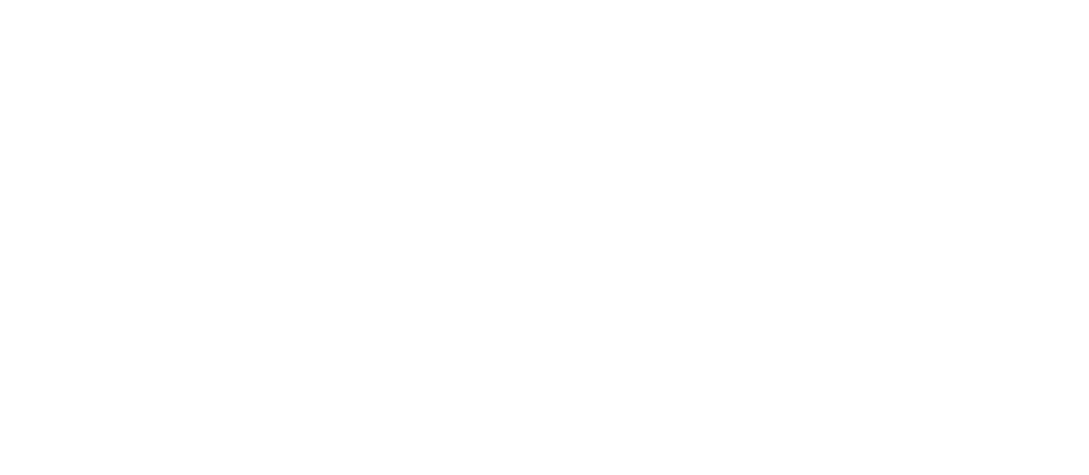

In [87]:
# NOTE: core.whitening() compares the string exactly, so it wants 'ZCA' and not 'zca'
white_sig, Z = whitening(
    Y=ext_sig,
    method=whitening_method.upper(),
    regularization="auto",
)

print(f"Whitened signal : {white_sig.shape}")
print(f"Whitening matrix: {Z.shape}")

##### I don't think I understand where the matrix reduction comes from via whitening #######
##### the non-whitened matrix is 1024 x  30720 while the whitened matrix is 1024 x 1024. #######

# A quick visual check: the covariance should go from "structured" to "identity".
# We only look at the first 100 rows, the full 1024 x 1024 matrix is unreadable

n_show = 100
cov_before = np.cov(ext_sig[:n_show])
cov_after = np.cov(white_sig[:n_show])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cov, title in zip(axes, [cov_before, cov_after],
                          ['Covariance before whitening', 'Covariance after whitening']):
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-np.abs(cov).max(), vmax=np.abs(cov).max())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

###### Why are there traces in the covariance matrix after whitening? I would expect these not to be here if I were looking
###### at an identity matrix

### Step 3: finding one source

Now the ICA proper. What we want is a vector `w` such that the projection `w.T @ white_sig` is as sparse as possible, where sparse means mostly flat with a handful of big spikes sticking out. Which is exactly what the firing pattern of a motor unit looks like.

Sparseness gets measured through a contrast function, here a smoothed version of `sign(x) * |x|^a` where `a` is the `opt_function_exp` you set earlier. Crank the exponent up and the optimization rewards a few very tall peaks over a lot of medium ones.

The update itself is the classic fastICA fixed point step,

```python
w_new = mean(X * g(w.T @ X)) - mean(g'(w.T @ X)) * w
```

followed by a normalization, repeated until `w` stops moving. That is what `delta = |w_new . w_old - 1|` is measuring: two unit vectors pointing the same way have a dot product of 1, so delta going to zero means the direction has settled. We stop when it drops below `opt_tol` or when we run out of iterations.

The `B` argument is the matrix of filters we have already accepted, and every step `w` gets orthogonalized against them so the optimization cannot wander back onto a unit we already have. On the first run `B` is empty and nothing happens.

In [88]:
# This is CBSS.my_fixed_point_alg, rewritten with a few more comments

def fixed_point(w, X, B, exponent=3, tol=1e-4, max_iter=100, deflation="gram-schmidt"):
    """
    Maximize the sparseness of the projection w.T @ X.

    Parameters:
    - w: np.ndarray, the initial separation vector (n_extended_channels,) ## forward model
    - X: np.ndarray, the whitened signal (n_extended_channels x n_samples)
    - B: np.ndarray, the filters (w?) already found, in columns. Used for the deflation
    - exponent: int, the 'a' of the contrast function, i.e. opt_function_exp
    - tol: float, stop when w stops moving by more (**less**??) than this #### How do we set this value??
    - max_iter: int, hard cap on the number of steps
    - deflation: str, how to keep w away from the filters already in B

    Returns:
    - w: np.ndarray, the optimized separation vector
    - k: int, how many iterations it actually took
    """

    # The contrast function and its derivative. ## G(x) and g(x) for negentropy
    # epsilon only keeps the expression differentiable around zero
    epsilon = 1e-3
    a = exponent
    g = lambda x: (epsilon + x**2) ** ((a - 3) / 2) * (a * x**2 + epsilon) ##### Where do these estimations of negentropy come from?? Can't find in Negro 2016
    gp = lambda x: (a - 1) * x * (epsilon + x**2) ** ((a - 5) / 2) * (a * x**2 + 3 * epsilon)

    delta = np.ones(max_iter)
    k = 0

    while delta[k] > tol and k < max_iter - 1:
        w_last = w.copy()

        # The projection of the data on the current filter, i.e. the current source estimate
        wTX = w.T @ X

        # The fixed point update itself
        A = np.mean(gp(wTX))                      ## mean(g'(w.T @ X)) from above text
        w = np.mean(X * g(wTX), axis=1) - A * w   ## w_new             from above text
 
        # Deflation: remove from w everything that lies along the filters we already accepted,
        # otherwise every run would converge onto the same, strongest motor unit
        if deflation == "gram-schmidt":
            w = gram_schmidt(w, B)
        elif deflation == "projection_deflation":
            w = w - (B @ B.T) @ w
            

        # Only the direction of w matters, so we keep it on the unit sphere
        w = w / np.linalg.norm(w)

        # Convergence: 1 minus the dot product between the new and the old direction
        ##### Equals 0 if perfectly converged, we just care if this value is less than our "tol" convergence value
        delta[k + 1] = abs(np.dot(w, w_last) - 1)
        k += 1

    return w, k

Converged in 8 iterations


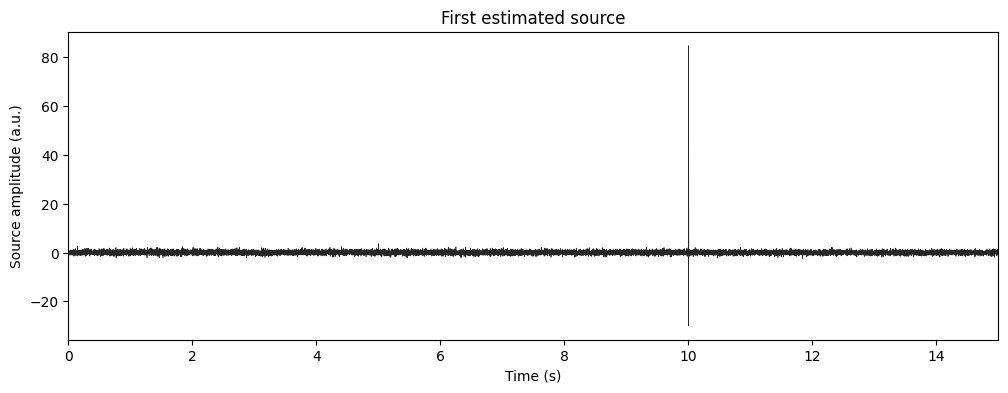

In [89]:
# Reproducibility: the initialization is random, so without a seed you get a different
# source every time you re-run the cell
np.random.seed(1909)

# No filters found yet, so the deflation matrix is empty
mu_filters = np.zeros((white_sig.shape[0], 1))

# 'random' initialization, as set in the configuration section
w = np.random.randn(white_sig.shape[0]) ### begin with a random guess for the weights (mixing/forward model)

w, n_steps = fixed_point(w, white_sig, mu_filters,
                         exponent=opt_function_exp,
                         tol=opt_tol,
                         max_iter=opt_max_iter)

# The source is simply the projection of the whitened data on the filter we just found
source = w.T @ white_sig ### (S = WTX)

print(f"Converged in {n_steps} iterations")

t = np.arange(source.size) / fs
plt.figure(figsize=(12, 4))
plt.plot(t, source, lw=0.5, color='0.15')
plt.xlabel('Time (s)')
plt.ylabel('Source amplitude (a.u.)')
plt.title('First estimated source')
plt.xlim(0, t[-1])
plt.show()

### Step 4: from source to spike train

If the previous step worked, the plot above is mostly flat with a set of peaks standing out of it. Those peaks are our candidate discharges, but not all of them are real, some are just noise that happened to line up nicely.

`est_spike_times()` tries to sort that out. It raises the source to a power first, which stretches the gap between tall and small peaks, then finds all the local maxima keeping at least 10 ms between them (since a motor neuron physically cannot fire twice faster than that). Then it takes the *heights* of those peaks and clusters them in two with k-means: the low cluster is noise, the high one is the spikes.

How cleanly those two clusters separate is the SIL we talked about in the configuration section. A source where spikes and noise form two obviously distinct clouds gets a SIL near 1, a source where the peak heights are one continuous smear gets something near 0.

Along with it we compute the CoV of the ISI, which is how regular the intervals between discharges are, and the firing rate. Those three numbers together decide wheter we accept the source or not, both for the peel off in a couple of steps and for the final clean up at the end.


In [90]:
spikes, sil, centroids = est_spike_times(source, fs, cluster=cluster_method)

# Coefficient of variation of the inter spike intervals, and firing rate
cov = cov_isi(spikes, fs)
fr = len(spikes) / (source.size / fs)

print(f"Spikes detected : {len(spikes)}")
print(f"Silhouette (SIL): {sil:.3f}   (threshold: {sil_th})")
print(f"CoV of the ISI  : {cov:.3f}   (threshold: {cov_th})")
print(f"Firing rate     : {fr:.2f} Hz")
print(f"K-means centroids (noise, spike): {np.sort(centroids)}")

Spikes detected : 357
Silhouette (SIL): 0.799   (threshold: 0.85)
CoV of the ISI  : 0.689   (threshold: 0.35)
Firing rate     : 23.80 Hz
K-means centroids (noise, spike): [0.69039555 2.3133036 ]


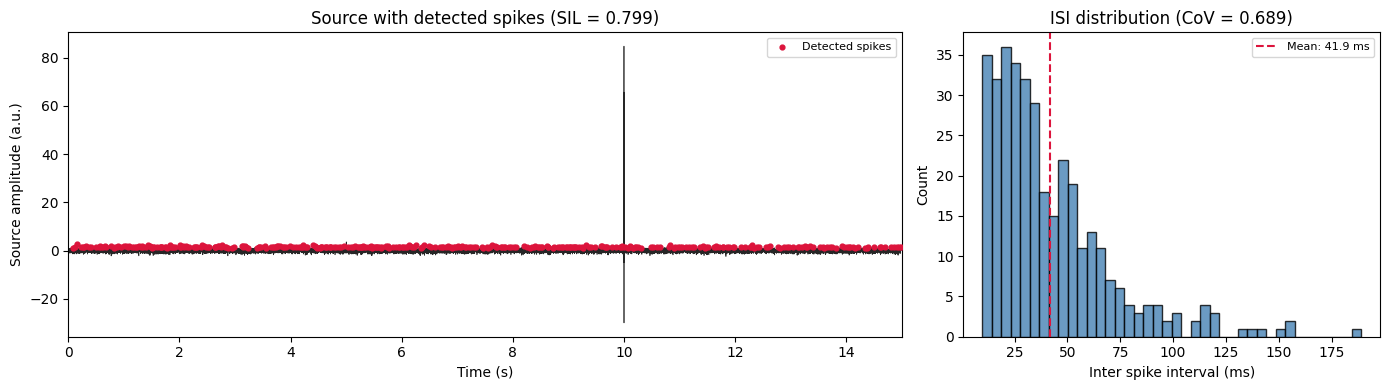

In [91]:
# Two views of the same source: the trace with the accepted peaks on it,
# and the distribution of the intervals between those peaks

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(t, source, lw=0.5, color='0.15')
if len(spikes) > 0:
    axes[0].scatter(spikes / fs, source[spikes], color='crimson', s=12, zorder=5, label='Detected spikes')
    axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Source amplitude (a.u.)')
axes[0].set_title(f'Source with detected spikes (SIL = {sil:.3f})')
axes[0].set_xlim(0, t[-1])

if len(spikes) > 2:
    isi = np.diff(spikes) / fs * 1000  # in milliseconds, easier to read
    axes[1].hist(isi, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    axes[1].axvline(np.mean(isi), color='crimson', ls='--', label=f'Mean: {np.mean(isi):.1f} ms')
    axes[1].legend(fontsize=8)
axes[1].set_xlabel('Inter spike interval (ms)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'ISI distribution (CoV = {cov:.3f})')

plt.tight_layout()
plt.show()

### Step 5: the refinement loop

The filter that came out of the fixed point algorithm is decent, but it was optimized against a purely mathematical criterion that knows nothing about motor neurons.

Instead of optimizing sparseness again, we rebuild the filter directly from the spikes we just found: the new `w` is simply the average of the whitened signal at the instants where the source fired. It is the same idea as a spike triggered average, and what you get is a filter tuned to the actual waveform of that particular unit rather than to a generic notion of sparseness. Then we do it again, and again, for as long as the CoV keeps going down, i.e. as long as the train keeps getting more regular. The first round that makes it worse, we stop.

This makes the train more regular, but it will happily drop discharges to get there. On a clean isometric contraction that is almost always the right call but on our concatenated signals, where a good chunk of the irregularity is an artifact of the concatenation itself it might aactually hurt the performance.

In [92]:
# This is CBSS.mimimize_covisi, rewritten with comments

def minimize_cov_isi(w, X, cov, fsamp, cluster='kmeans'):
    """
    Iteratively rebuild a motor unit filter from its own spike times, as long as
    the coefficient of variation of the inter spike intervals keeps decreasing.

    Parameters:
    - w: np.ndarray, the filter coming out of the fixed point algorithm
    - X: np.ndarray, the whitened signal
    - cov: float, the CoV of the ISI of the current source
    - fsamp: float, sampling frequency in Hz
    - cluster: str, the clustering method passed to est_spike_times

    Returns:
    - w, spikes, cov: the refined filter, its spike train and its CoV
    """

    # Anything larger than cov, so the first round always runs
    cov_last = cov + 1

    while cov < cov_last:
        # Current estimate of the source and of its discharges
        source = w.T @ X
        spikes, _, _ = est_spike_times(source, fsamp, cluster=cluster)

        cov_last = cov
        isi = np.diff(spikes / fsamp)
        cov = np.std(isi) / np.mean(isi)

        # The new filter is the average of the whitened signal at the discharge instants
        w = np.mean(X[:, spikes], axis=1)
        w = w / np.linalg.norm(w)

    return w, spikes, cov
    

In [93]:
# The refinement is only worth running if we have enough spikes to compute a
# meaningful CoV in the first place, hence the check on the spike count
### ALso don't want to do the reinfement loop if the spike is good already, refining could potentially get rid of good signal
if len(spikes) > 10 and refinement_loop:
    w_ref, _, cov_ref = minimize_cov_isi(w, white_sig, cov, fs, cluster=cluster_method)

    # Recompute everything with the refined filter
    source_ref = w_ref.T @ white_sig
    spikes_ref, sil_ref, centroids_ref = est_spike_times(source_ref, fs, cluster=cluster_method)
    fr_ref = len(spikes_ref) / (source_ref.size / fs)

    print(f"{'':<10}{'before':>10}{'after':>10}")
    print(f"{'SIL':<10}{sil:>10.3f}{sil_ref:>10.3f}")
    print(f"{'CoV':<10}{cov:>10.3f}{cov_ref:>10.3f}")
    print(f"{'FR (Hz)':<10}{fr:>10.2f}{fr_ref:>10.2f}")
    print(f"{'Spikes':<10}{len(spikes):>10d}{len(spikes_ref):>10d}")

    # From here on we work with the refined version
    w, source, spikes, sil, cov, centroids = w_ref, source_ref, spikes_ref, sil_ref, cov_ref, centroids_ref
else:
    print("Not enough spikes for the refinement loop, keeping the filter as it is")

              before     after
SIL            0.799     0.836
CoV            0.689     0.689
FR (Hz)        23.80     16.20
Spikes           357       243


### Step 6: peeling off

We have one motor unit now, and it is usually one of the units with the largest amplitude at the electrodes, so for as long as its action potentials remain in the signal the optimization converges back onto them whatever the initialization, which makes removing it the condition for reaching the second unit rather than a refinement of the first.

The removal is done by `peel_off()`, which starts from the spike triggered average of the signal around the discharges we found, that is the average of what the array recorded in a 40 ms window centred on each firing, and over enough discharges that average converges to the MUAP of that unit on every channel while anything uncorrelated with its firing tends to zero. The template is then convolved with the binary spike train, which reconstructs the contribution of that unit across the recording, and the reconstruction is subtracted from the signal, leaving a residual on which the next iteration operates and in which the units that were overlapped by this one can be separated.


We only do this for sources that cleared the thresholds, because peeling off a unit that was found in part removes some of its discharges from the signal and leaves the remainder behind, which later iterations then pick up as a fragment of a unit rather than as a unit. That is the reason for the `fr_peeloff` flag set in the configuration, which adds a minimum firing rate to the silhouette and CoV conditions, on the basis that a source discharging below the physiological range is more likely to be a partial find than a complete one.

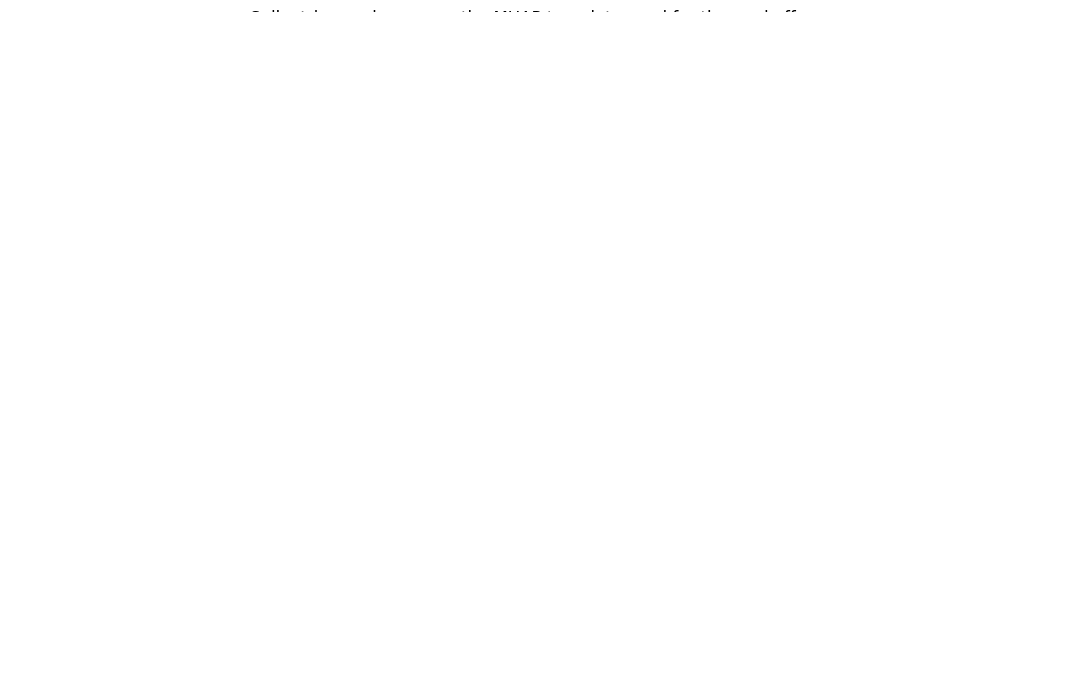

In [94]:
# The MUAP estimate: the average of the whitened signal in a window around each discharge
win = 0.04  # seconds, so 40 ms, wide enough to contain a whole MUAP
waveform = spike_triggered_average(white_sig, spikes, win=win, fsamp=fs)

# The actual subtraction. It returns the residual, the reconstructed contribution
# of this source, and the template it used
residual_sig, comp_sig, _ = peel_off(white_sig, spikes, win=win, fsamp=fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Left: the MUAP template on a handful of extended channels
# Note however, the template is calculated on the whitened signal,
# so it is not directly comparable to the original EMG and not make much sense

lag = np.arange(waveform.shape[1]) / fs * 1000 - win * 1000
for ch in range(0, waveform.shape[0], max(1, waveform.shape[0] // 8)):
    axes[0].plot(lag, waveform[ch], lw=0.8)
axes[0].axvline(0, color='crimson', ls='--', lw=1, label='Discharge')
axes[0].set_xlabel('Time relative to the discharge (ms)')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].set_title('Spike triggered average: the MUAP template used for the peel off')
axes[0].legend(fontsize=8)

# Right: one channel, before and after the subtraction, on a short window so it is readable
seg = slice(0, int(1.0 * fs))
axes[1].plot(t[seg], white_sig[0, seg], lw=0.6, color='0.15', label='Before peel off')
axes[1].plot(t[seg], residual_sig[0, seg], lw=0.6, color='crimson', alpha=0.8, label='After peel off')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Whitened amplitude (a.u.)')
axes[1].set_title('One extended channel, first second of the recording')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Step 7: the loop

Steps 3 through 6 produced one motor unit, and the rest come from repeating those four operations, with the difference between one round and the next lying in the two mechanisms that prevent convergence onto a unit we already have: the deflation, which orthogonalizes each new filter against every filter accepted so far and therefore removes those directions from the space the optimization can search, and the peel off, which addresses the same problem from the other side by taking the unit out of the signal.

`ica_n_iter` sets how many times we try, and it is an upper bound rather than a count of motor units, since a share of the iterations converge onto something that fails the thresholds and is discarded at the end, so the number of units at the end is typically three to four times smaller than the number of iterations.

The cell below is the `for` loop of `CBSS.decompose` condensed, printing one line per iteration. That log is what the class prints as it runs, and its shape is easier to read here, with the code that produced each number still in view. With 64 channels, an extension factor of 16 and 30 iterations it takes a couple of minutes.

In [95]:
# The number of iterations. The configuration says 100, which is a sensible value for a
# real run, but for a notebook 30 is enough to see what happens without waiting forever
n_iter = 30

np.random.seed(1909)

# The signal the loop works on. We copy it because the peel off modifies it in place,
# and we want to be able to re-run this cell without redoing the whitening
work_sig = white_sig.copy()
n_samples = work_sig.shape[1]

# Output containers, one slot per iteration
all_sources = np.zeros((n_iter, n_samples))
all_spikes = {i: np.array([], dtype=int) for i in range(n_iter)}
all_sil = np.zeros(n_iter)
all_covs = np.full(n_iter, np.inf)
all_centroids = {i: None for i in range(n_iter)}
all_filters = np.zeros((work_sig.shape[0], n_iter))

for i in range(n_iter):

    # --- Step 3: one separation vector -------------------------------------
    w = np.random.randn(work_sig.shape[0])
    w, _ = fixed_point(w, work_sig, all_filters,
                       exponent=opt_function_exp, tol=opt_tol, max_iter=opt_max_iter)

    # --- Step 4: source, spikes and quality metrics -------------------------
    s = w.T @ work_sig
    sp, si, ce = est_spike_times(s, fs, cluster=cluster_method)
    cv = cov_isi(sp, fs)

    # --- Step 5: refinement --------------------------------------------------
    if len(sp) > 10 and refinement_loop:
        w, _, cv = minimize_cov_isi(w, work_sig, cv, fs, cluster=cluster_method)
        s = w.T @ work_sig
        sp, si, ce = est_spike_times(s, fs, cluster=cluster_method)

    # Store, whatever the quality: the sorting out happens in step 8
    all_sources[i, :] = s
    all_spikes[i] = sp
    all_sil[i] = si
    all_covs[i] = cv
    all_centroids[i] = ce
    all_filters[:, i] = w

    firing_rate = len(sp) / (n_samples / fs)

    # --- Step 6: peel off, but only if the source is trustworthy -------------
    good = si > sil_th and cv < cov_th
    if fr_peeloff:
        good = good and firing_rate >= 10  # min_firing_rate, in Hz

    if peel_off and good and len(sp) > 5:
        work_sig, _, _ = peel_off(work_sig, sp, win=0.04, fsamp=fs)
        verdict = 'PEEL-OFF'
    else:
        verdict = 'kept, no peel off'

    if verbose_mode:
        print(f"{i:>3}: {verdict:<18} SIL: {si:.3f}  CoV: {cv:6.3f}  "
              f"FR: {firing_rate:5.2f} Hz  Spikes: {len(sp)}")

  0: kept, no peel off  SIL: 0.836  CoV:  0.689  FR: 16.20 Hz  Spikes: 243
  1: kept, no peel off  SIL: 0.792  CoV:  0.730  FR: 14.80 Hz  Spikes: 222
  2: kept, no peel off  SIL: 0.804  CoV:  0.780  FR: 14.53 Hz  Spikes: 218
  3: kept, no peel off  SIL: 0.815  CoV:  0.770  FR: 16.33 Hz  Spikes: 245
  4: kept, no peel off  SIL: 0.816  CoV:  0.853  FR: 19.47 Hz  Spikes: 292
  5: kept, no peel off  SIL: 0.802  CoV:  0.807  FR: 18.67 Hz  Spikes: 280
  6: kept, no peel off  SIL: 0.774  CoV:  0.749  FR: 18.47 Hz  Spikes: 277
  7: kept, no peel off  SIL: 0.843  CoV:  0.712  FR: 19.13 Hz  Spikes: 287
  8: kept, no peel off  SIL: 0.790  CoV:  0.673  FR: 13.87 Hz  Spikes: 208
  9: kept, no peel off  SIL: 0.848  CoV:  0.699  FR: 15.20 Hz  Spikes: 228
 10: kept, no peel off  SIL: 0.813  CoV:  0.863  FR: 16.20 Hz  Spikes: 243
 11: kept, no peel off  SIL: 0.825  CoV:  0.732  FR: 16.27 Hz  Spikes: 244
 12: kept, no peel off  SIL: 0.838  CoV:  0.727  FR: 18.00 Hz  Spikes: 270
 13: kept, no peel off  S

### Step 8: cleaning up

Everything the loop produced was kept, so the sorting happens here at the end, in two passes, first duplicates and then quality.

Duplicates come first because, deflation and peel off notwithstanding, two iterations can still land on the same motor unit, one of them catching it in full and the other catching two thirds of it. `remove_duplicates()` compares every pair of spike trains at the delay that aligns them best, searching up to `match_max_shift` of 100 ms since two filters looking at the same unit can be locked onto different parts of its MUAP, counts how many discharges then coincide within the `match_tol` of a millisecond, and treats the pair as one unit when the fraction of shared spikes reaches `match_th`, which we left at 30%. The grouping is transitive, so if A matches B and B matches C the three are collapsed into one group even when A and C would not have matched directly, and one representative of that group goes on to the next stage.

**Why transitive? If A != C, how can we say they are from the same MU? Doesn't this mean that A and C will have a lower match_th level but still considered a signle unit? And what does "collapsed" mean here? concate?**

The quality criteria are then applied by `remove_bad_sources()`, which requires a silhouette above `sil_th` and a firing rate above `min_firing_rate` and drops whatever fails either. The CoV is not part of that decision, since on our recordings a high CoV reflects the concatenation and the movement as often as it reflects the source, so it governs whether a unit is peeled off and never rejects anything.

**Don't we already include criteria for sil_th and min-firing_rate in our peel-off procedure? How is it possible that a unit is peeled off and yes would fail the quality criteria here?**

One detail to keep in mind is that the deduplication reindexes the sources, so the CoV array built inside the loop no longer corresponds to them position by position, and instead of carrying the old values through we recompute the CoV from the spike trains that survived.

In [96]:
print(f"Sources coming out of the loop: {all_sources.shape[0]}")

# --- Duplicates ------------------------------------------------------------
sources, spikes_final, sil_final, filters_final = remove_duplicates(
    all_sources, all_spikes, all_sil, all_filters, fs,
    max_shift=0.1,     # match_max_shift: largest delay we look for, in seconds
    tol=0.001,         # match_tol: two spikes closer than this count as the same one 
    #### Is it not biologically possible for two independent MUs to fire almost coincidentally? where does this threshold come from?
    #### Is it that we use tol as a counter so that when the amount of spikes that are less than tol = 30% we consider it the same?
    #### Also, general question about MUs, but if two MUs are involved in the same motor action, is it not plausible for them to have
    #### the same common input and then the entire concept of ICA and this pipeline fails? Two separate (but correlated) MUs are then treated as one IC?
    threshold=0.3,     # match_th: fraction of common spikes needed to call it a duplicate
)
print(f"After duplicate removal      : {sources.shape[0]}")

# The indices changed, so we rebuild the CoV array from the surviving spike trains
covs_final = np.array([cov_isi(spikes_final[i], fs) for i in range(sources.shape[0])])
centroids_final = {i: all_centroids[i] for i in range(sources.shape[0])}

# --- Bad sources -----------------------------------------------------------
sources, spikes_final, sil_final, filters_final, centroids_final = remove_bad_sources(
    sources, spikes_final, sil_final, filters_final, centroids_final, covs_final,
    threshold=sil_th,
    min_firing_rate=10,   # in Hz
    fsamp=fs,
    max_cov=cov_th,
)
print(f"After quality filtering      : {sources.shape[0]} motor units\n")

n_mu = sources.shape[0]
duration = sources.shape[1] / fs

for i in range(n_mu):
    cv = cov_isi(spikes_final[i], fs)
    print(f"MU {i:>2}: SIL {sil_final[i]:.3f}  CoV {cv:6.3f}  "
          f"FR {len(spikes_final[i]) / duration:5.2f} Hz  Spikes {len(spikes_final[i])}")

Sources coming out of the loop: 30
After duplicate removal      : 19
After quality filtering      : 3 motor units

MU  0: SIL 0.976  CoV  0.292  FR 13.93 Hz  Spikes 209
MU  1: SIL 0.982  CoV  0.226  FR 20.67 Hz  Spikes 310
MU  2: SIL 0.967  CoV  0.202  FR 33.33 Hz  Spikes 500


### Step 9: looking at the result

There are two plots here, and they answer different questions.

The raster is the output of the decomposition as it stands, one row per motor unit and one tick per discharge, and it is where you notice a row with a discharge rate above what a single motor neuron sustains, a row with so few spikes that it barely constitutes a train, or a row with a long silence in the middle, where the filter lost the unit partway through and picked it up again later.

The smoothed firing rates underneath come from converting each spike train into a binary signal and convolving it with a one second Hanning window, which turns a set of discrete events into a continuous estimate of discharge rate in pulses per second. That continuous form is what the decoders in this repo take as input, and what gets compared against force or kinematics.

Since we are looking at `grasp-holding`, which is several segments concatenated, a discontinuity on a segment boundary is expected and is not a failure of the decomposition.

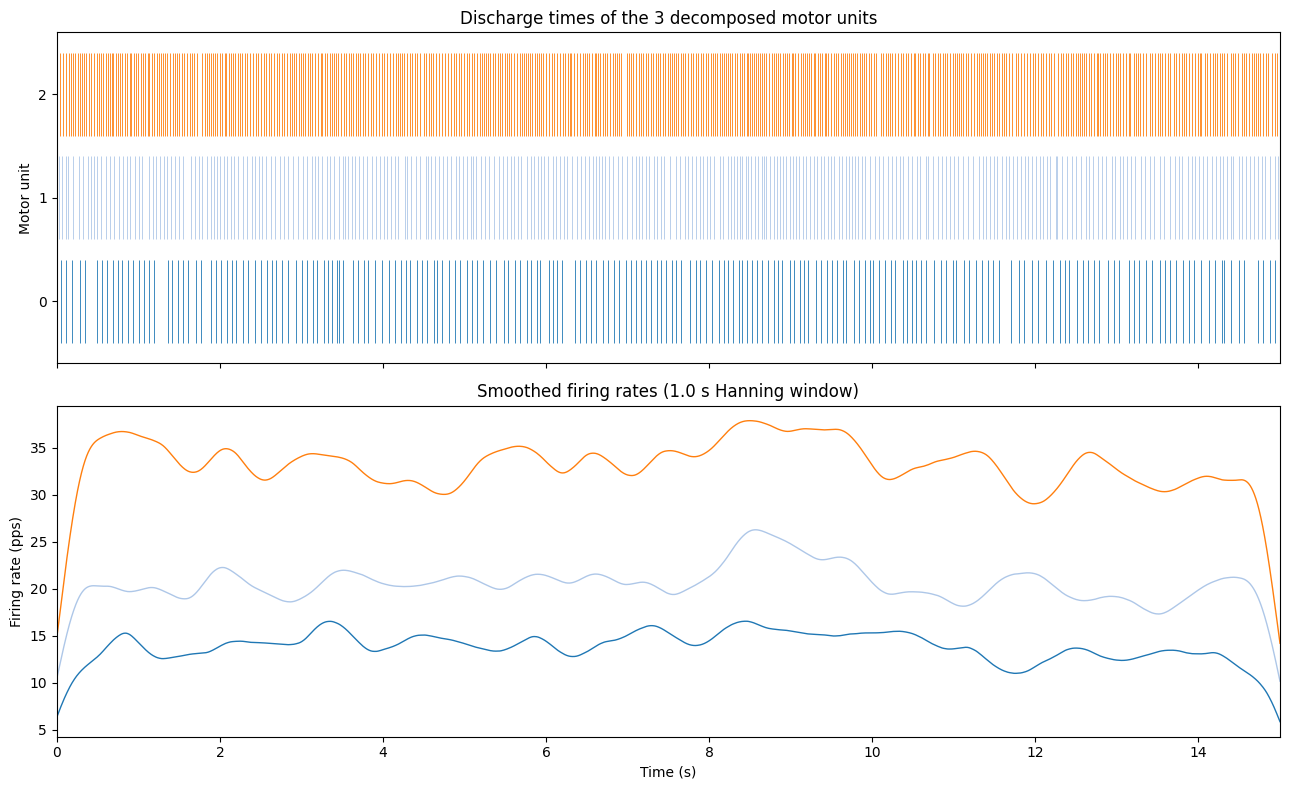

In [97]:
def plot_decomposition(spikes_dict, n_samples, fsamp, smooth_window=1.0):
    """
    Raster plot of the discharges plus the smoothed firing rate of each motor unit.

    Parameters:
    - spikes_dict: dict, spike indices per motor unit, as returned by the decomposition
    - n_samples: int, length of the decomposed signal in samples
    - fsamp: float, sampling frequency in Hz
    - smooth_window: float, width in seconds of the window used for the firing rate

    Returns:
    - axes: the two axes the plots were drawn on
    """
    n_units = len(spikes_dict)
    time = np.arange(n_samples) / fsamp

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    cmap = plt.get_cmap('tab20')

    # The Hanning window, normalized so the result is in discharges per second
    win_len = int(smooth_window * fsamp)
    window = np.hanning(win_len)
    window = window / (window.sum() / fsamp)

    for i in range(n_units):
        sp = np.asarray(spikes_dict[i], dtype=int)
        color = cmap(i % cmap.N)

        # Raster: a short vertical tick for every discharge
        axes[0].vlines(sp / fsamp, i - 0.4, i + 0.4, color=color, lw=0.6)

        # Firing rate: binary train convolved with the window
        binary = np.zeros(n_samples)
        binary[sp] = 1
        axes[1].plot(time, np.convolve(binary, window, mode='same'), color=color, lw=1.0)

    axes[0].set_ylabel('Motor unit')
    axes[0].set_yticks(range(n_units))
    axes[0].set_title(f'Discharge times of the {n_units} decomposed motor units')
    axes[0].set_ylim(-0.6, n_units - 0.4)

    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Firing rate (pps)')
    axes[1].set_title(f'Smoothed firing rates ({smooth_window:.1f} s Hanning window)')
    axes[1].set_xlim(0, time[-1])

    plt.tight_layout()
    return axes


if n_mu > 0:
    plot_decomposition(spikes_final, sources.shape[1], fs)
    plt.show()
else:
    print("No motor unit survived the filtering. Try lowering sil_th, or raising n_iter")

### Step 10: the short version

Having gone through what happens inside, here is the form this takes in a script, where every step from the extension to the clean up is one call to `CBSS.decompose()` and the parameters we have been setting by hand come from a config file, here [cbss.json](../src/configs/cbss.json), which is the baseline mentioned at the start of the configuration section.

Two properties of the constructor to be aware of. Any key it does not recognize is ignored with a printed warning, so a mistyped parameter name does not raise, it leaves the default in place, and the decomposition then runs as though that line of your config were absent. And the JSON stores the disabled filters as the string `"None"` rather than as a null, which is why we convert those back into `None` before passing anything in.

What comes back is the same six objects we assembled by hand, the sources, the spike trains, the silhouettes, the filters, the whitening matrix and the k-means centroids, and while the first four are what you inspect, the whitening matrix and the centroids are what allow these filters to be applied to a different piece of signal, which is what we do in the next step and what the real time decoder does continuously.

In [98]:
# Load the baseline configuration
with open(os.path.join(REPO_DIR, 'src', 'configs', 'cbss.json')) as f:
    cbss_config = json.load(f)['Config']

# The JSON stores disabled options as the string "None", turn them back into real None
cbss_config = {k: (None if v == "None" else v) for k, v in cbss_config.items()}

# Fewer iterations than the config asks for, again just to keep the notebook quick
cbss_config['ica_n_iter'] = 30

print(json.dumps(cbss_config, indent=2))

{
  "start_time": 0,
  "end_time": -1,
  "sampling_frequency": 2048,
  "bandpass": null,
  "bandpass_order": 2,
  "notch_frequency": 50,
  "notch_n_harmonics": 3,
  "notch_order": 2,
  "notch_width": 1,
  "ext_fact": 16,
  "whitening_method": "ZCA",
  "whitening_reg": "auto",
  "ica_n_iter": 30,
  "opt_initalization": "random",
  "opt_function_exp": 3,
  "opt_max_iter": 100,
  "opt_tol": 0.0001,
  "source_deflation": "gram-schmidt",
  "peel_off": true,
  "fr_peeloff": true,
  "cluster_method": "kmeans",
  "random_seed": 1909,
  "refinement_loop": true,
  "sil_th": 0.85,
  "cov_th": 0.35,
  "verbose_mode": true
}


In [99]:
# Everything from step 1 to step 8, in one call
decomposer = CBSS(**cbss_config)

sources_cbss, spikes_cbss, sil_cbss, filters_cbss, Z_cbss, centroids_cbss = decomposer.decompose(
    emg, fsamp=fs
)

print(f"\nCBSS found {sources_cbss.shape[0]} motor units, "
      f"our step by step version found {n_mu}")

[INFO] Extending signals by factor 16...

STARTING CBSS DECOMPOSITION
Max iterations: 30, Silhouette threshold: 0.850, CoV threshold: 0.350

Refinement loop for source 0 (initial Sil: 0.799, CoV: 0.689, Spikes: 357)
FR peel-off enabled
Refinement loop for source 1 (initial Sil: 0.781, CoV: 0.730, Spikes: 413)
FR peel-off enabled
Refinement loop for source 2 (initial Sil: 0.812, CoV: 0.780, Spikes: 363)
FR peel-off enabled
Refinement loop for source 3 (initial Sil: 0.790, CoV: 0.770, Spikes: 390)
FR peel-off enabled
Refinement loop for source 4 (initial Sil: 0.823, CoV: 0.853, Spikes: 347)
FR peel-off enabled
Refinement loop for source 5 (initial Sil: 0.765, CoV: 0.807, Spikes: 411)
FR peel-off enabled
Refinement loop for source 6 (initial Sil: 0.809, CoV: 0.749, Spikes: 376)
FR peel-off enabled
Refinement loop for source 7 (initial Sil: 0.810, CoV: 0.712, Spikes: 383)
FR peel-off enabled
Refinement loop for source 8 (initial Sil: 0.817, CoV: 0.673, Spikes: 413)
FR peel-off enabled
Refi

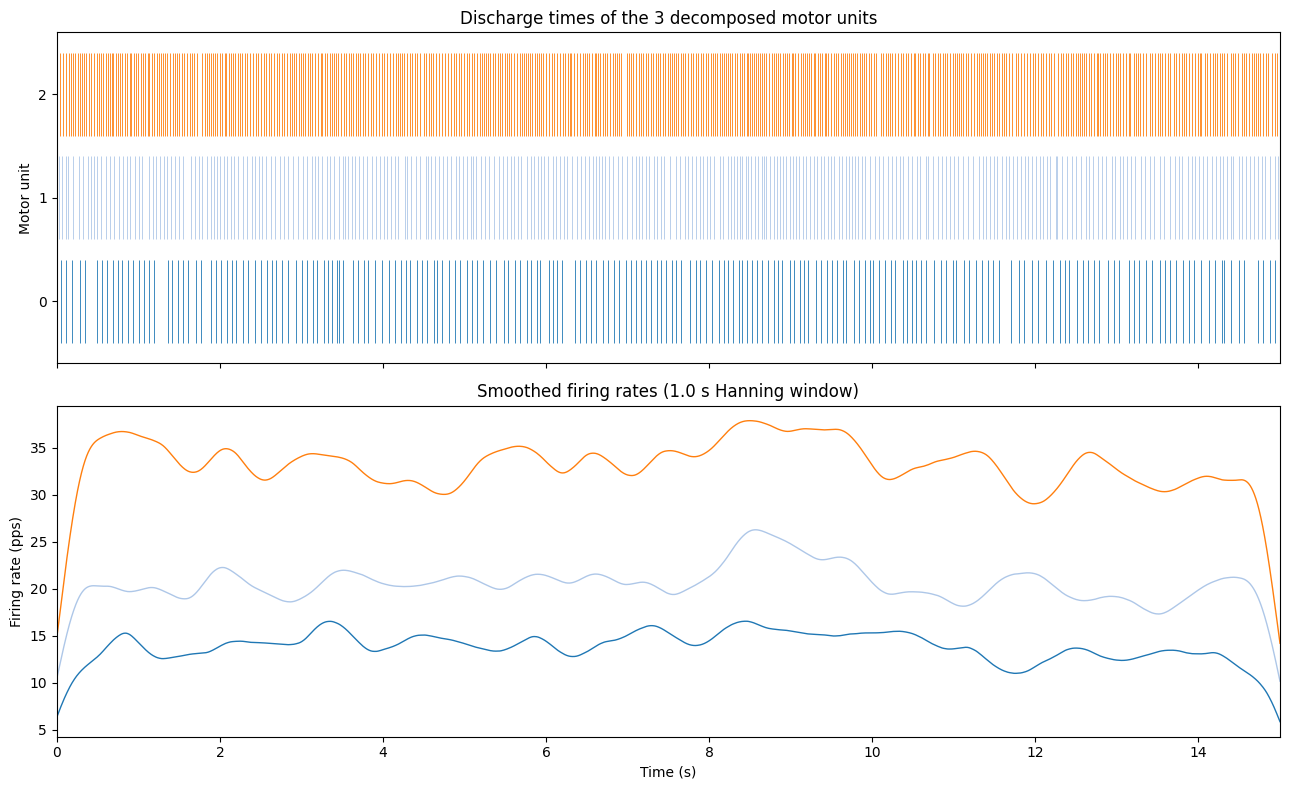

In [100]:
if sources_cbss.shape[0] > 0:
    plot_decomposition(spikes_cbss, sources_cbss.shape[1], fs)
    plt.show()

### A few things worth trying

The two runs above will not have produced the same motor units, since the initialization is random and the peel off modifies the signal as it goes, so the order in which units are discovered changes from run to run; what stays comparable is the number of units and their discharge rates.

There are a few things to try from here. Decomposing another phase, `default-holding` for instance, and comparing the two sets shows that different poses recruit different populations and that some units are absent from the other phase entirely. Lowering `sil_th` to 0.8 returns more units, and looking at their rasters afterwards tells you what that threshold is doing. Setting `refinement_loop = False` shows how much of the regularity in the CoV column came from the algorithm rather than from the muscle. Turning `peel_off` off returns the same few high amplitude units repeatedly, which is what that step exists to prevent.

That leaves the question of whether these units correspond to the ones in the muscle, which with simulated data can be checked directly.

## Step 11: ok, but was any of that right?

The pickle we loaded at the beginning carries, besides the EMG, the discharge times of every motor unit the simulator placed in the muscle, so the units we found can be taken one at a time and measured against the truth.

The code that does the comparing lives in [validation.py](../src/utils/validation.py) and is the same code used in [neuromotion.ipynb](./neuromotion.ipynb), so the procedure there is the one described here.

Two things to establish before we start. The first is that the comparison happens on spike times in seconds and not on sources or waveforms, at least on simulated data. A decomposed unit is a list of instants, a simulated unit is a list of instants, and the question is how much the two lists overlap; the sources and the MUAPs are there to look at and to diagnose with, but they take no part in the scoring.

The second is that our spike times are shifted with respect to the truth, because the filter carries a delay that comes from the extension, in that it can lock onto the beginning, the middle or the tail of the MUAP and displace the whole train by a few milliseconds. That displacement is constant, the same for every discharge of a given unit, so the comparison sweeps the shift and keeps the value that aligns the trains best, and without that sweep you would conclude you had found nothing at all, when you had found the unit three milliseconds late.

In [101]:
from src.utils.validation import check_time_shifted_matches, calculate_roa

### Getting the ground truth out of the pickle

The discharge times are under the `spikes` key, one array per simulated motor unit, holding sample indices at the same sampling frequency as the EMG, so dividing by `fs` is the only preparation they need.

The file holds a few hundred units, and most of them sit deep enough in the muscle that their contribution at the surface is below the noise, so they are not units a surface decomposition can recover, and a method reporting most of them is either an easy Nature paper or a mirage.

In [102]:
# Reload the pickle, this time for the ground truth rather than the EMG
result_pandas = pd.read_pickle(os.path.join(INPUT_DIR, filename))

if 'spikes' not in result_pandas:
    raise KeyError(f"No 'spikes' key in this file. What it does have: {list(result_pandas.keys())}")

gt_spikes = result_pandas['spikes']

# It can come as a list or as a dict depending on which version of Neuromotion produced it
if isinstance(gt_spikes, dict):
    gt_spikes = list(gt_spikes.values())

# Ground truth timings, in seconds. Empty units are kept so the indices stay
# the same as in the file, the matching skips them on its own
GT_timings = [np.asarray(sp) / fs for sp in gt_spikes]

n_gt_active = sum(1 for sp in GT_timings if len(sp) > 0)
print(f"Motor units in the simulation : {len(GT_timings)}")
print(f"Of those, actually firing     : {n_gt_active}")
print(f"Discharges in total           : {sum(len(sp) for sp in GT_timings)}")

Motor units in the simulation : 158
Of those, actually firing     : 158
Discharges in total           : 128625


### Putting the filters back on the whole recording

Before comparing anything there is a detour to make, since we decomposed `grasp-holding`, which is a set of segments glued end to end, so our spike times are on the timeline of that glued signal while the ground truth is on the timeline of the original recording, and comparing the two directly returns nothing.

The way around it is the property the rest of the pipeline rests on, that a motor unit filter is not tied to the piece of signal it was found on: taking `mu_filters` together with the whitening matrix `Z` and applying them to any EMG gives that unit's source over the new signal, so here we apply them to the full recording and the two timelines agree again.

That operation is, buffering aside, what the real time decoder does as well, with the new signal being the last couple hundred milliseconds from the amplifier rather than a recording on disk, and it is why `decompose()` returns `Z` and the centroids at all, since without them the filters cannot be applied to anything except the signal they were estimated from.

One caveat to state explicitly: `Z` was estimated on the holding phase, so reusing it across the recording assumes the noise covariance stays constant, and during the transitions it does not, with the result that the sources degrade in those stretches. You can accept that, or re-estimate `Z` on the full signal and accept instead that the filters no longer match the whitening they were derived with. Both are in use, and they give different sources over the transition segments.

In [103]:
# Same channels the decomposition ran on, otherwise the filters have the wrong length
if bad_channels:
    keep_ch = [ch for ch in range(emg_flat.shape[0]) if ch not in bad_channels]
    emg_full = emg_flat[keep_ch, :]
else:
    emg_full = emg_flat

# Steps 1 and 2 again, this time on the whole recording, reusing the Z we already have
ext_full = extension(emg_full, R)
ext_full -= np.mean(ext_full, axis=1, keepdims=True)
ext_full[:, : R * 2] = 0
ext_full[:, -R * 2 :] = 0
white_full = Z @ ext_full

# And here is the actual reuse: one matrix product gives us every source at once
sources_full = filters_final.T @ white_full
print(f"Sources over the full recording: {sources_full.shape}  (motor units x samples)")

# Spikes again, on the full length sources.
# We re-cluster with k-means here. In real time you would instead pass
# cluster='centroid' with the centroids saved during the decomposition,
# since you cannot run k-means on a buffer of 200 ms and expect anything sane
DC_timings = []
for i in range(sources_full.shape[0]):
    sp, _, _ = est_spike_times(sources_full[i], fs, cluster='kmeans')
    DC_timings.append(np.asarray(sp) / fs)
    print(f"MU {i:>2}: {len(sp):>4} discharges over the full recording "
          f"({len(sp) / (sources_full.shape[1] / fs):.2f} Hz)")

Sources over the full recording: (3, 79968)  (motor units x samples)
MU  0:  241 discharges over the full recording (6.17 Hz)
MU  1:  373 discharges over the full recording (9.55 Hz)
MU  2:  652 discharges over the full recording (16.70 Hz)


### The actual comparison

`check_time_shifted_matches()` takes both lists and compares every decomposed unit against every simulated one, sliding our train from minus ten to plus ten milliseconds in steps of half a millisecond and, at each shift, counting how many discharges fall within a millisecond of each other in both directions: one direction gives the fraction of true discharges we recovered, so what is missing from it is what we failed to find, and the other gives the fraction of our discharges that appear in the truth, so what is missing there is what we produced without cause. Both fractions have to reach thirty per cent before the pair is considered further, which removes coincidental overlaps from the comparison.

For the pairs that pass that screening it computes the Rate of Agreement, `RoA = C / (C + O + I) * 100`, where `C` counts the discharges both sides agree on, `O` those only the simulator has and `I` those only we have, so that missed and added spikes both lower the result, which is why it is the number usually reported. The matching underneath is one to one, so a single decomposed spike cannot be counted twice against two different true spikes.

Reading the result: above ninety per cent is the same unit, between seventy and ninety is the same unit with part of its discharges missing, most often because it stopped firing partway through and the filter lost it, and below fifty the results get iffy. The literature usually counts 30% as the threshold to declare wheter an unit has been found or not. While it is three times as much as the usual match between different motor units (around 10%) it still means that 70% of the spieks are not shared, which is not a great result for me. 

Note: The code is quite slow, being a nested loop over every pair of units times forty-one shifts, and with a few hundred simulated units that adds up. It returns three objects rather than two, the matches that qualified, the best match for each of our units regardless of whether it qualified, and the full matrix of everything against everything.

In [104]:
# Note the three return values
best_matches, dc_best_matches, match_matrix = check_time_shifted_matches(
    GT_timings, DC_timings,
    max_shift=0.01,             # +/- 10 ms of delay searched
    shift_step=0.0005,          # in 0.5 ms steps
    min_match_percentage=0.3,   # both directions must reach 30% to qualify
)


CHECKING TIME-SHIFTED MATCHES (OPTIMIZED)
Testing shifts from -10.0ms to +10.0ms
Step size: 0.5ms
Progress: 430/474 comparisons (90.7%)
GT MU 145 <-> DC MU 1: 92.6% (GT->DC), 93.6% (DC->GT) at -10.0ms shift -> RoA: 87.0% (C:349, O:28, I:24)
Progress: 474/474 comparisons (100.0%)
1 time-shifted matches found above 30.0% bidirectional threshold

BEST MATCH FOR EACH DC MOTOR UNIT (regardless of threshold)
[BELOW THRESHOLD] DC MU 0 -> GT MU 118: 4.4% (GT->DC), 13.3% (DC->GT) at -4.0ms shift -> RoA: 3.4% (C:32, O:688, I:209)
[MATCHED] DC MU 1 -> GT MU 145: 92.6% (GT->DC), 93.6% (DC->GT) at -10.0ms shift -> RoA: 87.0% (C:349, O:28, I:24)
[BELOW THRESHOLD] DC MU 2 -> GT MU 126: 11.1% (GT->DC), 11.0% (DC->GT) at +0.0ms shift -> RoA: 5.9% (C:72, O:575, I:580)


### Reading the output

The log above prints a good deal, and the section to read is the one at the bottom, where each decomposed unit appears next to its best partner in the ground truth whether or not that partner cleared the threshold, since a unit that missed the cut by a little is a different case from one that matched nothing.

The table below holds the same information in a form that is easier to scan, and the three counts in it say how a unit failed where the RoA alone says only that it did: a large `O` next to a small `I` describes a motor unit whose discharges we recovered in part, which points at the filter losing the unit rather than at the wrong unit, while a large `I` says we are producing spikes the simulator never generated, which points at a filter responding to something other than the unit it is tracking.

In [105]:
rows = []
for dc_idx in sorted(dc_best_matches):
    gt_idx, shift, roa, match_ij, match_ji, counts = dc_best_matches[dc_idx]
    rows.append({
        'DC MU': dc_idx,
        'GT MU': gt_idx,
        'RoA (%)': round(roa, 1),
        'shift (ms)': round(shift * 1000, 1),
        'found of GT (%)': round(match_ij * 100, 1),
        'real of ours (%)': round(match_ji * 100, 1),
        'C': counts['C'],
        'O (missed)': counts['O'],
        'I (invented)': counts['I'],
        'SIL': round(sil_final[dc_idx], 3),
    })

summary = pd.DataFrame(rows).sort_values('RoA (%)', ascending=False).reset_index(drop=True)
display(summary)

print(f"\nUnits above 90% RoA: {(summary['RoA (%)'] >= 90).sum()} / {len(summary)}")
print(f"Units above 70% RoA: {(summary['RoA (%)'] >= 70).sum()} / {len(summary)}")
print(f"Mean RoA           : {summary['RoA (%)'].mean():.1f}%")

,DC MU,GT MU,RoA (%),shift (ms),found of GT (%),real of ours (%),C,O (missed),I (invented),SIL
0,1,145,87.0,-10.0,92.6,93.6,349,28,24,0.982
1,2,126,5.9,0.0,11.1,11.0,72,575,580,0.967
2,0,118,3.4,-4.0,4.4,13.3,32,688,209,0.976



Units above 90% RoA: 0 / 3
Units above 70% RoA: 1 / 3
Mean RoA           : 32.1%


# In Conclusion

If the runs are somewhat consistent, you have probably found, at best, one or two motor units corresponding to real simulated ones

While this is probably because the n of iterations is low, there is certainly some optimization to be done with the config parameter. I know it's not the most interesting task to be done, but play around with the parameters a bit and see if you manage to optimize it.

Next, there is something I would like you to try. You should have in the required reading, seen a paper detailing how to apply this decomposition in real time. 
Decomposition as is is too slow to apply online, and for this reason various research came up with tricks to skip the ICA steps when trying to read motor unit activity in a real time manner. If you find yourself with time on your hands, try and reproduce their methods down below, it's good training and the more you understand the less difficult it will be going forward.

# Sandbox